In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import joblib
import warnings
import imblearn
import matplotlib.pyplot as plt
import shap
import numpy as np
import optuna
import mlflow

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    RandomizedSearchCV,
    cross_validate,
)
from sklearn.metrics import classification_report, confusion_matrix, PrecisionRecallDisplay, precision_recall_curve
from sklearn.inspection import permutation_importance
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.model_selection import cross_val_predict

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

#Modèles
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

In [26]:


# df_total = pd.DataFrame()

# df_application_train = pd.read_csv(r"DataExcel/application_train.csv")
# df_bureau = pd.read_csv(r"DataExcel\bureau.csv")
# df_previous_application = pd.read_csv(r"DataExcel\previous_application.csv")
# df_installments_payments = pd.read_csv(r"DataExcel/installments_payments.csv")
# df_credit_card_balance = pd.read_csv(r"DataExcel\credit_card_balance.csv")

# df_total["SK_ID_CURR"] = df_application_train["SK_ID_CURR"]
# df_total = df_application_train.set_index("SK_ID_CURR")[[]]

# df_bureau = df_bureau.sort_values("SK_ID_CURR")

# credit_active = df_bureau.groupby("SK_ID_CURR")["CREDIT_ACTIVE"].value_counts().unstack(fill_value=0)
# df_total = df_total.merge(credit_active,on="SK_ID_CURR", how="left")
# credit_type = df_bureau.groupby("SK_ID_CURR")["CREDIT_TYPE"].value_counts().unstack(fill_value=0)
# df_total = df_total.merge(credit_type,on="SK_ID_CURR", how="left")
# DAYS_CREDIT = df_bureau.groupby("SK_ID_CURR")["DAYS_CREDIT"].mean()
# df_total = df_total.merge(DAYS_CREDIT,on="SK_ID_CURR", how="left")
# CREDIT_DAY_OVERDUE = df_bureau.groupby("SK_ID_CURR")["CREDIT_DAY_OVERDUE"].sum() 
# df_total = df_total.merge(CREDIT_DAY_OVERDUE,on="SK_ID_CURR", how="left")
# DAYS_CREDIT_ENDDATE = df_bureau.groupby("SK_ID_CURR")["DAYS_CREDIT_ENDDATE"].mean()
# df_total = df_total.merge(DAYS_CREDIT_ENDDATE,on="SK_ID_CURR", how="left")
# DAYS_ENDDATE_FACT = df_bureau.groupby("SK_ID_CURR")["DAYS_ENDDATE_FACT"].mean()
# df_total = df_total.merge(DAYS_ENDDATE_FACT,on="SK_ID_CURR", how="left")
# AMT_CREDIT_MAX_OVERDUE = df_bureau.groupby("SK_ID_CURR")["AMT_CREDIT_MAX_OVERDUE"].mean()
# df_total = df_total.merge(AMT_CREDIT_MAX_OVERDUE,on="SK_ID_CURR", how="left")
# CNT_CREDIT_PROLONG = df_bureau.groupby("SK_ID_CURR")["CNT_CREDIT_PROLONG"].sum()
# df_total = df_total.merge(CNT_CREDIT_PROLONG,on="SK_ID_CURR", how="left")
# AMT_CREDIT_SUM = df_bureau.groupby("SK_ID_CURR")["AMT_CREDIT_SUM"].mean()
# df_total = df_total.merge(AMT_CREDIT_SUM,on="SK_ID_CURR", how="left")
# AMT_CREDIT_SUM_DEBT = df_bureau.groupby("SK_ID_CURR")["AMT_CREDIT_SUM_DEBT"].mean()
# df_total = df_total.merge(AMT_CREDIT_SUM_DEBT,on="SK_ID_CURR", how="left")
# AMT_CREDIT_SUM_LIMIT = df_bureau.groupby("SK_ID_CURR")["AMT_CREDIT_SUM_LIMIT"].mean()
# df_total = df_total.merge(AMT_CREDIT_SUM_LIMIT,on="SK_ID_CURR", how="left")
# DAYS_CREDIT_UPDATE = df_bureau.groupby("SK_ID_CURR")["DAYS_CREDIT_UPDATE"].mean()
# df_total = df_total.merge(DAYS_CREDIT_UPDATE,on="SK_ID_CURR", how="left")



# df_previous_application = df_previous_application.sort_values("SK_ID_CURR")

# NAME_CONTRACT_STATUS = df_previous_application.groupby("SK_ID_CURR")["NAME_CONTRACT_STATUS"].value_counts().unstack(fill_value=0)
# df_total = df_total.merge(NAME_CONTRACT_STATUS,on="SK_ID_CURR", how="left")
# NAME_CONTRACT_TYPE = df_previous_application.groupby("SK_ID_CURR")["NAME_CONTRACT_TYPE"].value_counts().unstack(fill_value=0)
# df_total = df_total.merge(NAME_CONTRACT_TYPE,on="SK_ID_CURR", how="left")
# CODE_REJECT_REASON = df_previous_application.groupby("SK_ID_CURR")["CODE_REJECT_REASON"].value_counts().unstack(fill_value=0)
# df_total = df_total.merge(CODE_REJECT_REASON,on="SK_ID_CURR", how="left")
# AMT_CREDIT = df_previous_application.groupby("SK_ID_CURR")["AMT_CREDIT"].mean()
# df_total = df_total.merge(AMT_CREDIT,on="SK_ID_CURR", how="left")
# AMT_APPLICATION = df_previous_application.groupby("SK_ID_CURR")["AMT_APPLICATION"].mean()
# df_total = df_total.merge(AMT_APPLICATION,on="SK_ID_CURR", how="left")
# DAYS_DECISION = df_previous_application.groupby("SK_ID_CURR")["DAYS_DECISION"].mean()
# df_total = df_total.merge(DAYS_DECISION,on="SK_ID_CURR", how="left")
# CNT_PAYMENT = df_previous_application.groupby("SK_ID_CURR")["CNT_PAYMENT"].mean()
# df_total = df_total.merge(CNT_PAYMENT,on="SK_ID_CURR", how="left")



# df_installments_payments = df_installments_payments.sort_values("SK_ID_CURR")

# NUM_INSTALMENT_NUMBER = df_installments_payments.groupby("SK_ID_CURR")["NUM_INSTALMENT_NUMBER"].sum()
# df_total = df_total.merge(NUM_INSTALMENT_NUMBER,on="SK_ID_CURR", how="left")
# DAYS_INSTALMENT = df_installments_payments.groupby("SK_ID_CURR")["DAYS_INSTALMENT"].sum()
# df_total = df_total.merge(DAYS_INSTALMENT,on="SK_ID_CURR", how="left")
# DAYS_ENTRY_PAYMENT = df_installments_payments.groupby("SK_ID_CURR")["DAYS_ENTRY_PAYMENT"].mean()
# df_total = df_total.merge(DAYS_ENTRY_PAYMENT,on="SK_ID_CURR", how="left")
# AMT_INSTALMENT = df_installments_payments.groupby("SK_ID_CURR")["AMT_INSTALMENT"].mean()
# df_total = df_total.merge(AMT_INSTALMENT,on="SK_ID_CURR", how="left")
# AMT_PAYMENT = df_installments_payments.groupby("SK_ID_CURR")["AMT_PAYMENT"].mean()
# df_total = df_total.merge(AMT_PAYMENT,on="SK_ID_CURR", how="left")



# df_credit_card_balance = df_credit_card_balance.sort_values("SK_ID_CURR")
# NAME_CONTRACT_STATUS = df_credit_card_balance.groupby("SK_ID_CURR")["NAME_CONTRACT_STATUS"].value_counts().unstack(fill_value=0)
# df_total = df_total.merge(NAME_CONTRACT_STATUS,on="SK_ID_CURR", how="left")
# df_credit_card_balance = df_credit_card_balance.drop(columns=['NAME_CONTRACT_STATUS', 'SK_ID_PREV'])

# list_credt = []

# for i in df_credit_card_balance:
#     if i!= "SK_ID_CURR":
#         df_tempo = df_credit_card_balance.groupby("SK_ID_CURR")[i].mean()
#         df_total = df_total.merge(df_tempo,on="SK_ID_CURR", how="left")

# df_application_train = df_application_train.set_index("SK_ID_CURR")

# TARGET = df_application_train["TARGET"]
# df_total = df_total.merge(TARGET,on="SK_ID_CURR", how="left")
# CODE_GENDER = df_application_train.groupby("SK_ID_CURR")["CODE_GENDER"].value_counts().unstack(fill_value=0)
# df_total = df_total.merge(CODE_GENDER,on="SK_ID_CURR", how="left")
# FLAG_OWN_CAR = df_application_train.groupby("SK_ID_CURR")["FLAG_OWN_CAR"].value_counts().unstack(fill_value=0)
# df_total = df_total.merge(FLAG_OWN_CAR,on="SK_ID_CURR", how="left")
# FLAG_OWN_REALTY = df_application_train.groupby("SK_ID_CURR")["FLAG_OWN_REALTY"].value_counts().unstack(fill_value=0)
# df_total = df_total.merge(FLAG_OWN_REALTY,on="SK_ID_CURR", how="left")
# CNT_CHILDREN = df_application_train["CNT_CHILDREN"]
# df_total = df_total.merge(CNT_CHILDREN,on="SK_ID_CURR", how="left")
# AMT_INCOME_TOTAL = df_application_train["AMT_INCOME_TOTAL"]
# df_total = df_total.merge(AMT_INCOME_TOTAL,on="SK_ID_CURR", how="left")
# AMT_CREDIT = df_application_train["AMT_CREDIT"]
# df_total = df_total.merge(AMT_CREDIT,on="SK_ID_CURR", how="left")
# AMT_ANNUITY = df_application_train["AMT_ANNUITY"]
# df_total = df_total.merge(AMT_ANNUITY,on="SK_ID_CURR", how="left")
# AMT_GOODS_PRICE = df_application_train["AMT_GOODS_PRICE"]
# df_total = df_total.merge(AMT_GOODS_PRICE,on="SK_ID_CURR", how="left")
# NAME_INCOME_TYPE = df_application_train.groupby("SK_ID_CURR")["NAME_INCOME_TYPE"].value_counts().unstack(fill_value=0)
# df_total = df_total.merge(NAME_INCOME_TYPE,on="SK_ID_CURR", how="left")
# NAME_EDUCATION_TYPE = df_application_train.groupby("SK_ID_CURR")["NAME_EDUCATION_TYPE"].value_counts().unstack(fill_value=0)
# df_total = df_total.merge(NAME_EDUCATION_TYPE,on="SK_ID_CURR", how="left")
# NAME_FAMILY_STATUS = df_application_train.groupby("SK_ID_CURR")["NAME_FAMILY_STATUS"].value_counts().unstack(fill_value=0)
# df_total = df_total.merge(NAME_FAMILY_STATUS,on="SK_ID_CURR", how="left")
# NAME_HOUSING_TYPE = df_application_train.groupby("SK_ID_CURR")["NAME_HOUSING_TYPE"].value_counts().unstack(fill_value=0)
# df_total = df_total.merge(NAME_HOUSING_TYPE,on="SK_ID_CURR", how="left")
# DAYS_BIRTH = df_application_train["DAYS_BIRTH"]
# df_total = df_total.merge(DAYS_BIRTH,on="SK_ID_CURR", how="left")
# DAYS_EMPLOYED = df_application_train["DAYS_EMPLOYED"]
# df_total = df_total.merge(DAYS_EMPLOYED,on="SK_ID_CURR", how="left")
# OCCUPATION_TYPE = df_application_train.groupby("SK_ID_CURR")["OCCUPATION_TYPE"].value_counts().unstack(fill_value=0)
# df_total = df_total.merge(OCCUPATION_TYPE,on="SK_ID_CURR", how="left")
# CNT_FAM_MEMBERS = df_application_train["CNT_FAM_MEMBERS"]
# df_total = df_total.merge(CNT_FAM_MEMBERS,on="SK_ID_CURR", how="left")
# REGION_RATING_CLIENT = df_application_train["REGION_RATING_CLIENT"]
# df_total = df_total.merge(REGION_RATING_CLIENT,on="SK_ID_CURR", how="left")
# EXT_SOURCE_1 = df_application_train["EXT_SOURCE_1"]
# df_total = df_total.merge(EXT_SOURCE_1,on="SK_ID_CURR", how="left")
# EXT_SOURCE_2 = df_application_train["EXT_SOURCE_2"]
# df_total = df_total.merge(EXT_SOURCE_2,on="SK_ID_CURR", how="left")
# EXT_SOURCE_3 = df_application_train["EXT_SOURCE_3"]
# df_total = df_total.merge(EXT_SOURCE_3,on="SK_ID_CURR", how="left")

# print(df_total.info())

# missing_pct = df_total.isnull().mean()
# cols_to_drop = missing_pct[missing_pct > 0.5].index
# df_total = df_total.drop(columns=cols_to_drop)
# df_total = df_total.fillna(df_total.mean(numeric_only=True))

# print(df_total.info())

# df_total.to_csv("df_total.csv")




282686 24825
<class 'pandas.core.frame.DataFrame'>
------------------------ TRAIN ------------------------
Seuil opti : 0.53, Fonction de Cout : 127640.00000000003


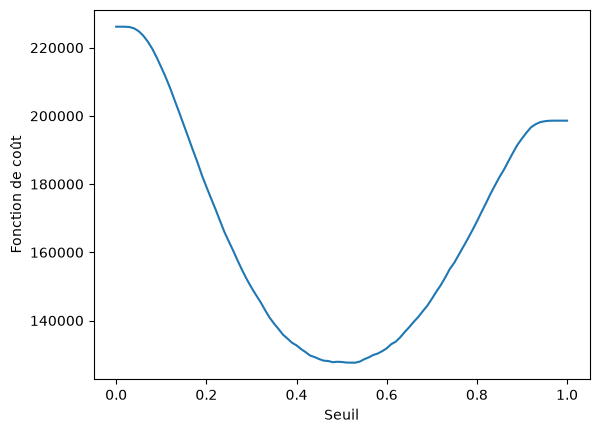

---------------------------- TEST ----------------------------
              precision    recall  f1-score   support

           0       0.96      0.76      0.85     56538
           1       0.19      0.64      0.30      4965

    accuracy                           0.75     61503
   macro avg       0.58      0.70      0.57     61503
weighted avg       0.90      0.75      0.81     61503

                    feature  importance_pct
114            EXT_SOURCE_2        4.790476
115            EXT_SOURCE_3        4.604762
92               DAYS_BIRTH        4.576190
65              AMT_ANNUITY        4.214286
54              AMT_PAYMENT        3.945238
64             AMT_CREDIT_y        3.873810
49              CNT_PAYMENT        3.688095
66          AMT_GOODS_PRICE        3.588095
52       DAYS_ENTRY_PAYMENT        3.485714
93            DAYS_EMPLOYED        3.228571
25           AMT_CREDIT_SUM        3.121429
51          DAYS_INSTALMENT        3.080952
50    NUM_INSTALMENT_NUMBER        3.0

['model_trained']

In [ ]:
import warnings
warnings.filterwarnings("ignore")
# mlflow.autolog()

df_total = pd.read_csv("df_total.csv")

X = df_total.drop(columns=['TARGET','SK_ID_CURR'])
y = df_total['TARGET']

print(sum(df_total['TARGET']==0),sum(df_total['TARGET']==1))


X_train, X_test, y_train, y_test = train_test_split(X, y,stratify=y, train_size=0.8, random_state=42)

RFC = RandomForestClassifier(random_state=42,class_weight='balanced',n_jobs=-1)
XGBC = XGBClassifier(scale_pos_weight=282686/24825, random_state=42,n_jobs=-1)
LGBC = LGBMClassifier(class_weight='balanced',random_state=42,verbosity=-1,n_jobs=-1,)

print(type(X_train))

scaler = StandardScaler()


DC = Pipeline([
    ("scaler", scaler),
    ("model", DummyClassifier())
])

RC = Pipeline([
    ("scaler", scaler),
    ("model", RidgeClassifier())
])

RFC = Pipeline([
    ("model",RFC)
])

XGBC = Pipeline([
    ("model",XGBC)
])

LGBMC = Pipeline([
    ("model",LGBC)
])

models = {"RC": RC,"RFC": RFC,"XGBC": XGBC,"LGBMC": LGBMC}

print("------------------------ TRAIN ------------------------")

# for model_name,model in models.items():
#     scores = cross_validate(model, X_train,y_train, scoring = {"roc_auc": "roc_auc", "balanced_accuracy":"balanced_accuracy"})
#     print(f"{model_name} : roc_auc = {scores['test_roc_auc'].mean():.2f}, Balanced Accuracy = {scores['test_balanced_accuracy'].mean():.2f}")

def objective(trial):

    param = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 200, 1500, step=100
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.005, 0.2, log=True
        ),
        "num_leaves": trial.suggest_int(
            "num_leaves", 7, 63
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 3, 12
        ),
        "min_child_samples": trial.suggest_int(
            "min_child_samples", 5, 100
        ),
        "min_child_weight": trial.suggest_float(
            "min_child_weight", 1e-4, 10, log=True
        ),
        "min_split_gain": trial.suggest_float(
            "min_split_gain", 0, 2
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.5, 1.0
        ),
        "subsample_freq": trial.suggest_int(
            "subsample_freq", 1, 10
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.5, 1.0
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-5, 20, log=True
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-5, 20, log=True
        )
    }

    model = LGBMClassifier(
        **param,
        random_state=42,
        class_weight="balanced",
        verbosity=-1,
        n_jobs=-1
    )


    scores = cross_validate(
        model,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=5
    )

    return scores["test_score"].mean()

# optuna.logging.set_verbosity(optuna.logging.WARNING)

# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=50)
# params = study.best_params
# print("LGBMC Best params :", study.best_params)
# print("LGBMC Best params :", study.best_value)


LGBMC_opti = LGBMClassifier(
    n_estimators=1500,
    learning_rate=0.01574433925644241,
    num_leaves=29,
    max_depth=7,
    min_child_samples=44,
    min_child_weight=0.003590728446885754,
    min_split_gain=0.3601804004799223,
    subsample=0.573040144048012,
    subsample_freq=7,
    colsample_bytree=0.5600819542922837,
    reg_alpha=13.511994686449535,
    reg_lambda=14.322171162412452,
    random_state=42,
    class_weight="balanced",
    verbosity=-1,
    n_jobs=-1
)

LGBMC_opti_pipeline = Pipeline([
    ("model",LGBMC_opti)
])

# with mlflow.start_run():
# scores = cross_validate(LGBMC_opti_pipeline, X_train,y_train, scoring = {"roc_auc": "roc_auc", "balanced_accuracy":"balanced_accuracy"})
# print(f"LGBMC OPTI : roc_auc = {scores['test_roc_auc'].mean():.2f}, Balanced Accuracy = {scores['test_balanced_accuracy'].mean():.2f}")
# mlflow.log_metric("cv_auc", CV_ba)
# mlflow.log_metric("cv_balanced_accuracy", CV_auc)

threshold = thresholds = [i / 100 for i in range(101)]

train_predict = cross_val_predict(LGBMC_opti_pipeline,X_train,y_train,method='predict_proba')[:,1]
total_fonction = []
total_seuil = []
for seuil in threshold:
    y_pred_train = (train_predict >= seuil).astype(int)
    #print(f"Threshold : {i}")
    classfication = classification_report(y_train, y_pred_train,output_dict=True)
    #print(classfication)
    #print(f"Pourcentage de 0 raté : {(1-classfication['0']['recall'])*100:.2f}%, Pourcentage de 1 raté : {(1-classfication['1']['recall'])*100:.2f}%")
    Fonction_cout = 10*(1-classfication['1']['recall'])*classfication['1']['support']+(1-classfication['0']['recall'])*classfication['0']['support']
    #print(f"Fonction de coût : {Fonction_cout:.2f}\n")
    total_fonction.append(Fonction_cout)
    total_seuil.append(seuil)
seuil_opti = total_seuil[total_fonction.index(min(total_fonction))]
print(f"Seuil opti : {seuil_opti}, Fonction de Cout : {min(total_fonction)}")
plt.plot(threshold,total_fonction)
plt.xlabel("Seuil")
plt.ylabel("Fonction de coût")
plt.show()

model_trained = LGBMC_opti_pipeline.fit(X_train,y_train)
y_pred_test = model_trained.predict_proba(X_test)[:,1]
y_test_seuil = (y_pred_test>=seuil_opti).astype(int)
classification = classification_report(y_test, y_test_seuil)
print("---------------------------- TEST ----------------------------")
print(classification)

importance = model_trained.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance_pct": importance / importance.sum() * 100
}).sort_values("importance_pct", ascending=False)

print(feature_importance.head(30))

joblib.dump(model_trained,"model_trained")



In [ ]:
import fastapi
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Literal

model_trained = joblib.load("model_trained")

app = FastAPI()

class Features(BaseModel):
    SK_ID_CURR: int
    Active_x: float
    Bad_debt: float
    Closed: float
    Sold: float
    Another_type_of_loan: float
    Car_loan: float
    Cash_loan_non_earmarked: float
    Consumer_credit: float
    Credit_card: float
    Interbank_credit: float
    Loan_for_business_development: float
    Loan_for_purchase_of_shares_margin_lending: float
    Loan_for_the_purchase_of_equipment: float
    Loan_for_working_capital_replenishment: float
    Microloan: float
    Mobile_operator_loan: float
    Mortgage: float
    Real_estate_loan: float
    Unknown_type_of_loan: float
    DAYS_CREDIT: float
    CREDIT_DAY_OVERDUE: float
    DAYS_CREDIT_ENDDATE: float
    DAYS_ENDDATE_FACT: float
    AMT_CREDIT_MAX_OVERDUE: float
    CNT_CREDIT_PROLONG: float
    AMT_CREDIT_SUM: float
    AMT_CREDIT_SUM_DEBT: float
    AMT_CREDIT_SUM_LIMIT: float
    DAYS_CREDIT_UPDATE: float
    Approved_x: float
    Canceled: float
    Refused_x: float
    Unused_offer: float
    Cash_loans: float
    Consumer_loans: float
    Revolving_loans: float
    XNA_x: float
    CLIENT: float
    HC: float
    LIMIT: float
    SCO: float
    SCOFR: float
    SYSTEM: float
    VERIF: float
    XAP: float
    XNA_y: float
    AMT_CREDIT_x: float
    AMT_APPLICATION: float
    DAYS_DECISION: float
    CNT_PAYMENT: float
    NUM_INSTALMENT_NUMBER: float
    DAYS_INSTALMENT: float
    DAYS_ENTRY_PAYMENT: float
    AMT_INSTALMENT: float
    AMT_PAYMENT: float
    TARGET: Literal[0, 1]
    M: Literal[0, 1]
    F: Literal[0, 1]
    XNA: Literal[0, 1]
    N_x: Literal[0, 1]
    Y_x: Literal[0, 1]
    Y_y: Literal[0, 1]
    N_y: Literal[0, 1]
    CNT_CHILDREN: int
    AMT_INCOME_TOTAL: float
    AMT_CREDIT_y: float
    AMT_ANNUITY: float
    AMT_GOODS_PRICE: float
    Working: Literal[0, 1]
    State_servant: Literal[0, 1]
    Commercial_associate: Literal[0, 1]
    Pensioner: Literal[0, 1]
    Unemployed: Literal[0, 1]
    Student: Literal[0, 1]
    Businessman: Literal[0, 1]
    Maternity_leave: Literal[0, 1]
    Secondary_secondary_special: Literal[0, 1]
    Higher_education: Literal[0, 1]
    Incomplete_higher: Literal[0, 1]
    Lower_secondary: Literal[0, 1]
    Academic_degree: Literal[0, 1]
    Single_not_married: Literal[0, 1]
    Married: Literal[0, 1]
    Civil_marriage: Literal[0, 1]
    Widow: Literal[0, 1]
    Separated: Literal[0, 1]
    Unknown: Literal[0, 1]
    House_apartment: Literal[0, 1]
    Rented_apartment: Literal[0, 1]
    With_parents: Literal[0, 1]
    Municipal_apartment: Literal[0, 1]
    Office_apartment: Literal[0, 1]
    Co_op_apartment: Literal[0, 1]
    DAYS_BIRTH: int
    DAYS_EMPLOYED: int
    Laborers: Literal[0, 1]
    Core_staff: Literal[0, 1]
    Accountants: Literal[0, 1]
    Managers: Literal[0, 1]
    Drivers: Literal[0, 1]
    Sales_staff: Literal[0, 1]
    Cleaning_staff: Literal[0, 1]
    Cooking_staff: Literal[0, 1]
    Private_service_staff: Literal[0, 1]
    Medicine_staff: Literal[0, 1]
    Security_staff: Literal[0, 1]
    High_skill_tech_staff: Literal[0, 1]
    Waiters_barmen_staff: Literal[0, 1]
    Low_skill_Laborers: Literal[0, 1]
    Realty_agents: Literal[0, 1]
    Secretaries: Literal[0, 1]
    IT_staff: Literal[0, 1]
    HR_staff: Literal[0, 1]
    CNT_FAM_MEMBERS: float
    REGION_RATING_CLIENT: int
    EXT_SOURCE_2: float
    EXT_SOURCE_3: float

features = {
    "Active_x": 2.0,
    "Bad debt": 0.0,
    "Closed": 6.0,
    "Sold": 0.0,
    "Another type of loan": 0.0,
    "Car loan": 0.0,
    "Cash loan (non-earmarked)": 0.0,
    "Consumer credit": 4.0,
    "Credit card": 4.0,
    "Interbank credit": 0.0,
    "Loan for business development": 0.0,
    "Loan for purchase of shares (margin lending)": 0.0,
    "Loan for the purchase of equipment": 0.0,
    "Loan for working capital replenishment": 0.0,
    "Microloan": 0.0,
    "Mobile operator loan": 0.0,
    "Mortgage": 0.0,
    "Real estate loan": 0.0,
    "Unknown type of loan": 0.0,
    "DAYS_CREDIT": -874.0,
    "CREDIT_DAY_OVERDUE": 0.0,
    "DAYS_CREDIT_ENDDATE": -349.0,
    "DAYS_ENDDATE_FACT": -697.5,
    "AMT_CREDIT_MAX_OVERDUE": 1681.029,
    "CNT_CREDIT_PROLONG": 0.0,
    "AMT_CREDIT_SUM": 108131.945625,
    "AMT_CREDIT_SUM_DEBT": 49156.2,
    "AMT_CREDIT_SUM_LIMIT": 7997.14125,
    "DAYS_CREDIT_UPDATE": -499.875,
    "Approved_x": 1.0,
    "Canceled": 0.0,
    "Refused_x": 0.0,
    "Unused offer": 0.0,
    "Cash loans": 0.0,
    "Consumer loans": 1.0,
    "Revolving loans": 0.0,
    "XNA_x": 0.0,
    "CLIENT": 0.0,
    "HC": 0.0,
    "LIMIT": 0.0,
    "SCO": 0.0,
    "SCOFR": 0.0,
    "SYSTEM": 0.0,
    "VERIF": 0.0,
    "XAP": 1.0,
    "XNA_y": 0.0,
    "AMT_CREDIT_x": 179055.0,
    "AMT_APPLICATION": 179055.0,
    "DAYS_DECISION": -606.0,
    "CNT_PAYMENT": 24.0,
    "NUM_INSTALMENT_NUMBER": 190.0,
    "DAYS_INSTALMENT": -5605.0,
    "DAYS_ENTRY_PAYMENT": -315.42105263157896,
    "AMT_INSTALMENT": 11559.24710526316,
    "AMT_PAYMENT": 11559.24710526316,
    "M": 1.0,
    "F": 0.0,
    "XNA": 0.0,
    "N_x": 1.0,
    "Y_x": 0.0,
    "Y_y": 1.0,
    "N_y": 0.0,
    "CNT_CHILDREN": 0.0,
    "AMT_INCOME_TOTAL": 202500.0,
    "AMT_CREDIT_y": 406597.5,
    "AMT_ANNUITY": 24700.5,
    "AMT_GOODS_PRICE": 351000.0,
    "Working": 1.0,
    "State servant": 0.0,
    "Commercial associate": 0.0,
    "Pensioner": 0.0,
    "Unemployed": 0.0,
    "Student": 0.0,
    "Businessman": 0.0,
    "Maternity leave": 0.0,
    "Secondary / secondary special": 1.0,
    "Higher education": 0.0,
    "Incomplete higher": 0.0,
    "Lower secondary": 0.0,
    "Academic degree": 0.0,
    "Single / not married": 1.0,
    "Married": 0.0,
    "Civil marriage": 0.0,
    "Widow": 0.0,
    "Separated": 0.0,
    "Unknown": 0.0,
    "House / apartment": 1.0,
    "Rented apartment": 0.0,
    "With parents": 0.0,
    "Municipal apartment": 0.0,
    "Office apartment": 0.0,
    "Co-op apartment": 0.0,
    "DAYS_BIRTH": -9461.0,
    "DAYS_EMPLOYED": -637.0,
    "Laborers": 1.0,
    "Core staff": 0.0,
    "Accountants": 0.0,
    "Managers": 0.0,
    "Drivers": 0.0,
    "Sales staff": 0.0,
    "Cleaning staff": 0.0,
    "Cooking staff": 0.0,
    "Private service staff": 0.0,
    "Medicine staff": 0.0,
    "Security staff": 0.0,
    "High skill tech staff": 0.0,
    "Waiters/barmen staff": 0.0,
    "Low-skill Laborers": 0.0,
    "Realty agents": 0.0,
    "Secretaries": 0.0,
    "IT staff": 0.0,
    "HR staff": 0.0,
    "CNT_FAM_MEMBERS": 1.0,
    "REGION_RATING_CLIENT": 2.0,
    "EXT_SOURCE_2": 0.8629485927471776,
    "EXT_SOURCE_3": 0.1393757800997895,
}

@app.post("\Question")
def Question(features :Features):
    features = features.model_dump()
    df_features = pd.DataFrame([features])
    y_test_pred = model_trained.predict_proba(df_features)
    for i in y_test_pred:
        output = i
    print(f"Crédit Accordé : {output[0]*100:.2f}%, Crédit Refusé : {output[1]*100:.2f}%")
    
        

Question(features)


Crédit Accordé : 44.33%, Crédit Refusé : 55.67%
